In [ ]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# --- Paths ---
municipalities_shp = r"c:\Users\SHIELD-HTMIRDS\postprocess\data\raw\shapefiles\Mun_Albay.shp" 
cleaned_raster = r"c:\Users\SHIELD-HTMIRDS\postprocess\data\processed\rasters"

In [19]:
# Load municipalities
muni = gpd.read_file(municipalities_shp)

# Will reproject per raster to match CRS

# Collect results in a list
results = []

# List all cleaned rasters
raster_files = glob.glob(os.path.join(cleaned_raster, "*.tif"))
print(f"Found {len(raster_files)} cleaned rasters.")

for raster_path in raster_files:
    raster_name = os.path.basename(raster_path)
    print(f"Processing raster: {raster_name}")

    # Open raster to get CRS
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        raster_nodata = src.nodata if src.nodata is not None else 0

    # Reproject municipalities to raster CRS
    muni_proj = muni.to_crs(raster_crs)

    # Compute zonal stats
    stats = zonal_stats(
        muni_proj,
        raster_path,
        stats=["max"],
        nodata=raster_nodata
    )

    # Append results
    for m, s in zip(muni_proj["NAME_2"], stats):
        results.append({
            "raster": raster_name,
            "municipality": m,
            "max_flood": s["max"] if s["max"] is not None else 0
        })


Found 11 cleaned rasters.
Processing raster: pre_RP_00001_1.tif
Processing raster: pre_RP_00002_1.tif
Processing raster: pre_RP_00005_1.tif
Processing raster: pre_RP_00010_1.tif
Processing raster: pre_RP_00025_1.tif
Processing raster: pre_RP_00050_1.tif
Processing raster: pre_RP_00100_1.tif
Processing raster: pre_RP_00200_1.tif
Processing raster: pre_RP_00250_1.tif
Processing raster: pre_RP_00500_1.tif
Processing raster: pre_RP_01000_1.tif


In [23]:
# Convert results to DataFrame
df = pd.DataFrame(results)
df.head()

,raster,municipality,max_flood
0,pre_RP_00001_1.tif,Bacacay,0.700112
1,pre_RP_00001_1.tif,Bato Lake,0.000000
2,pre_RP_00001_1.tif,Camalig,0.000000
3,pre_RP_00001_1.tif,Daraga,0.000000
4,pre_RP_00001_1.tif,Guinobatan,0.000000


In [30]:
# Filter out zero floods
df = df[df["max_flood"] > 0]

# Filter only coastal municipalities
coastal_munis = [
    "Legazpi City", "Bacacay", "Tiwi", "Tabaco City", "Santo Domingo",
    "Libon", "Oas", "Malilipot", "Rapu-Rapu", "Pio Duran", "Malinao",
    "Ligao City", "Manito"
]
df = df[df["municipality"].isin(coastal_munis)]

# Extract return period from filename (e.g., RP_01000 → 1000)
df["return_period"] = (
    df["raster"]
    .str.extract(r"RP_(\d+)_")[0]
    .astype(int)
)

# Convert Return Period to AEP (%)
df["AEP_percent"] = 100 / df["return_period"]

# Keep AEPs ≤ 50% and remove 100%
df = df[(df["AEP_percent"] <= 50) & (df["AEP_percent"] < 100)]

# Sort by AEP
df = df.sort_values("AEP_percent")


In [32]:
# Get unique municipalities (sorted for consistency)
municipalities = sorted(df["municipality"].unique())

# Use a palette with enough distinct colors
base_palette = sns.color_palette("tab10", n_colors=len(municipalities))
# Alternatives: "Set1", "Dark2"

# Explicit color mapping (prevents duplication)
color_map = dict(zip(municipalities, base_palette))

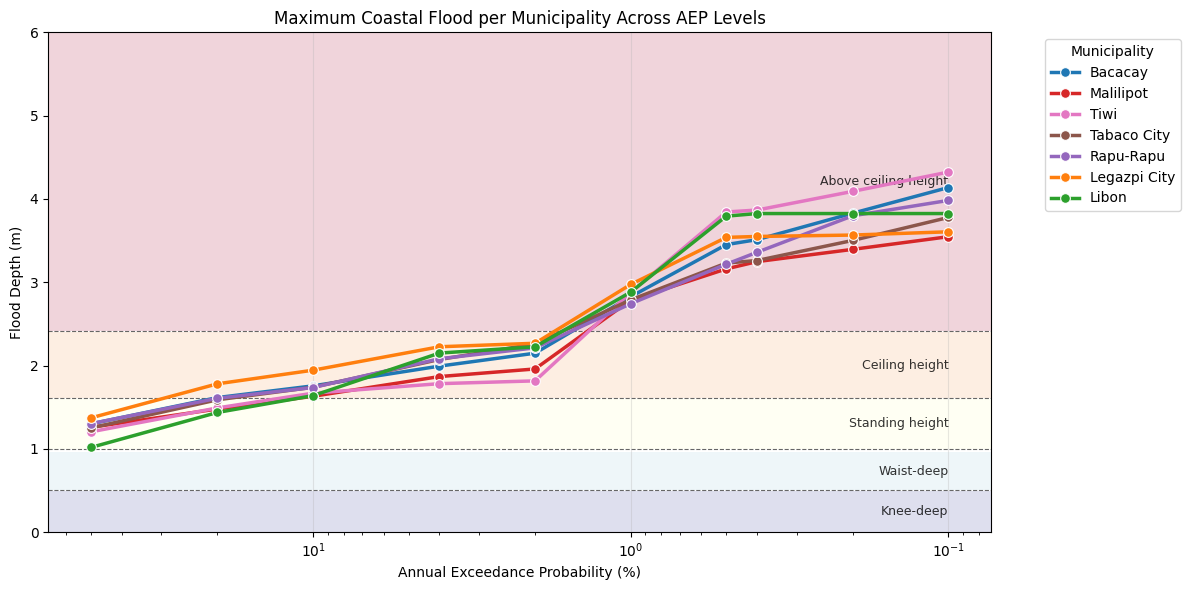

In [40]:
flood_classes = [
    (0.00, 0.49, "#4b4fa3", "Knee-deep"),
    (0.50, 0.96, "#a6cee3", "Waist-deep"),
    (1.00, 1.60, "#ffffbf", "Standing height"),
    (1.61, 2.40, "#f4a261", "Ceiling height"),
    (2.41, 6.00, "#b1123b", "Above ceiling height"),
]

plt.figure(figsize=(12, 6))

# Background flood-depth bands + labels
for ymin, ymax, color, label in flood_classes:
    plt.axhspan(
        ymin, ymax,
        facecolor=color,
        alpha=0.18,
        zorder=0
    )

    # Centered label in each band
    plt.text(
        x=df["AEP_percent"].min(),        # left side of plot
        y=(ymin + ymax) / 2,
        s=label,
        va="center",
        ha="right",
        fontsize=9,
        color="black",
        alpha=0.8
    )

# Dashed threshold lines
thresholds = [0.50, 1.00, 1.61, 2.41]
for t in thresholds:
    plt.axhline(
        y=t,
        color="black",
        linestyle="--",
        linewidth=0.8,
        alpha=0.6,
        zorder=1
    )

sns.lineplot(
    data=df,
    x="AEP_percent",
    y="max_flood",
    hue="municipality",
    palette=color_map,
    marker="o",
    linewidth=2.5,
    markersize=7,
    markeredgecolor="white",
    markeredgewidth=0.8,
    zorder=3
)


plt.title("Maximum Coastal Flood per Municipality Across AEP Levels")
plt.xlabel("Annual Exceedance Probability (%)")
plt.ylabel("Flood Depth (m)")
plt.xticks(sorted(df["AEP_percent"].unique()))
plt.xscale("log") # Log scale for better visibility (optional)
plt.gca().invert_xaxis()
plt.ylim(0, 6)
plt.grid(True, axis="x", alpha=0.3)
plt.legend(title="Municipality", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Save the figure
plt.savefig(r"c:\Users\SHIELD-HTMIRDS\postprocess\outputs\coastal_flood_municipalities.png", dpi=300, bbox_inches="tight")
plt.show()
